In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import InterpolatedUnivariateSpline_SPF, EMP_PSF
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

2026-01-24 18:18:32.094925: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("../docs/tutorials/tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

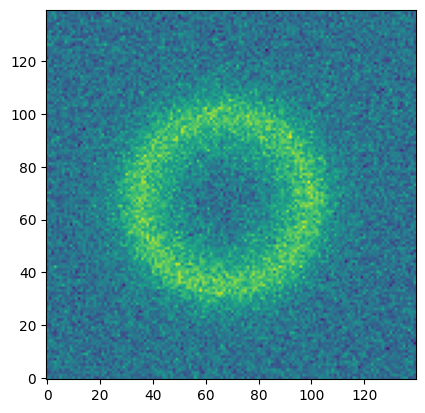

In [3]:
name = "inject_disk_inc75_spf0_betaneg.fits"
target_img = jnp.array(fits.getdata("inject_disk_inc0_spf0_betaneg.fits"))
plt.imshow(target_img,origin='lower')
err_map = jnp.ones(target_img.shape)*0.1

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['inclination'] = 5
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5


In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)

In [5]:
opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

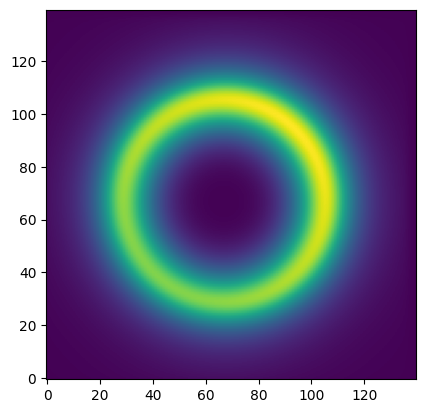

In [6]:
plt.imshow(opt.get_model(),origin='lower')

In [7]:
fit_keys = ['sma', 'inclination', 'position_angle', 'beta','knot_values']
logscaled_params = ['knot_values', 'inclination']
array_params = ['knot_values']
bounds = ([0, 0, 0,-5, np.zeros(opt.spf_params["num_knots"])],
          [150, 180, 400, 5, 1e4*np.ones(opt.spf_params["num_knots"])])

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_img, err_map, use_grad = True, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.20121D+04    |proj g|=  3.22894D+01

At iterate    1    f=  7.22052D+03    |proj g|=  3.38727D+01

At iterate    2    f=  6.40671D+03    |proj g|=  3.37601D+01

At iterate    3    f=  5.96023D+03    |proj g|=  3.36443D+01

At iterate    4    f=  5.87916D+03    |proj g|=  3.36303D+01

At iterate    5    f=  5.84476D+03    |proj g|=  3.35965D+01

At iterate    6    f=  5.78882D+03    |proj g|=  3.35221D+01

At iterate    7    f=  5.65764D+03    |proj g|=  3.33365D+01

At iterate    8    f=  5.32521D+03    |proj g|=  3.27581D+01

At iterate    9    f=  5.25498D+03    |proj g|=  5.32839D+01

At iterate   10    f=  5.20601D+03    |proj g|=  3.25983D+01

At iterate   11    f=  5.17501D+03    |proj g|=  3.26103D+01

At iterate   12    f=  5.09694D+03    |proj g|=  3.26270D+01

At iterate   13    f=  5.0


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': np.float64(24.856802450530026), 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(0.5255610215034014), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(0.5431930682255774), 'position_angle': np.float64(47.9866733789304), 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.08715574, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.08715574, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.19353299, 0.79693388, 1.        , 0.29676105, 0.70591336],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(3743.06507226, dtype=float64)}


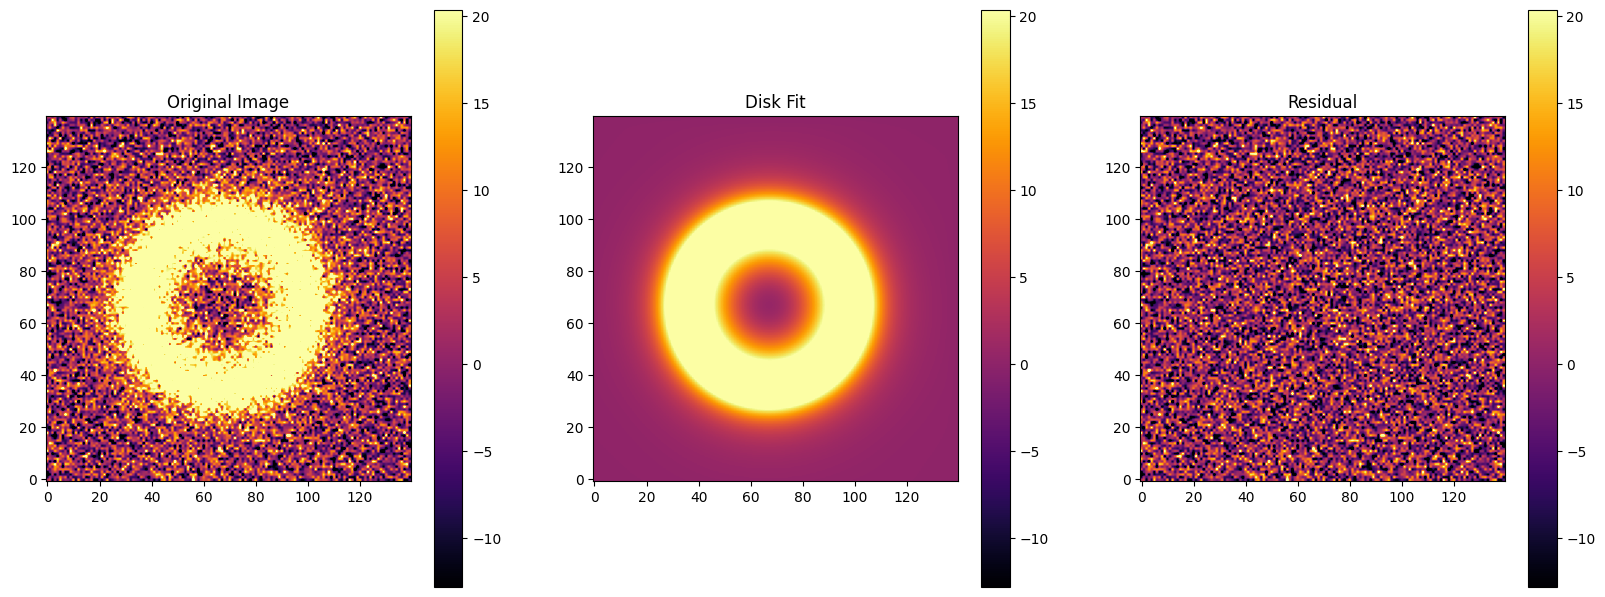

In [8]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout
plt.savefig('{}_scipyminimize_img.png'.format(name))

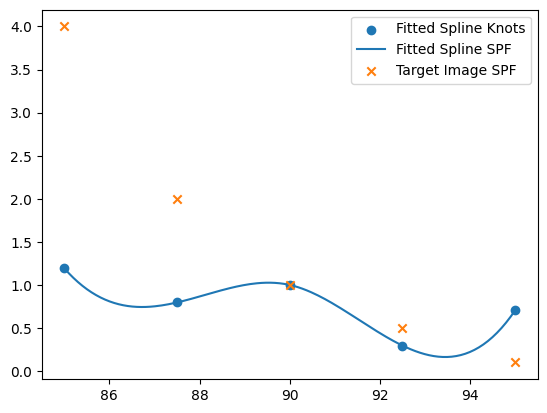

In [9]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[4.0,2.0,1.0,0.5,0.1],marker='x',zorder=10)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.savefig('{}_scipyminimize_spf.png'.format(name))

In [10]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=2000, burns=500)

Running burn-in...


100%|██████████| 500/500 [04:05<00:00,  2.04it/s]


Running production...


100%|██████████| 2000/2000 [12:54<00:00,  2.58it/s]


Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': np.float64(24.916831396418797), 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(0.5270433368005045), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(0.008506634200330638), 'position_angle': np.float64(59.06044234894216), 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.08715574, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.08715574, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.44266557, 0.83275186, 1.        , 0.25824367, 1.7787638 ],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(2478.71723926, dtype=float64)}


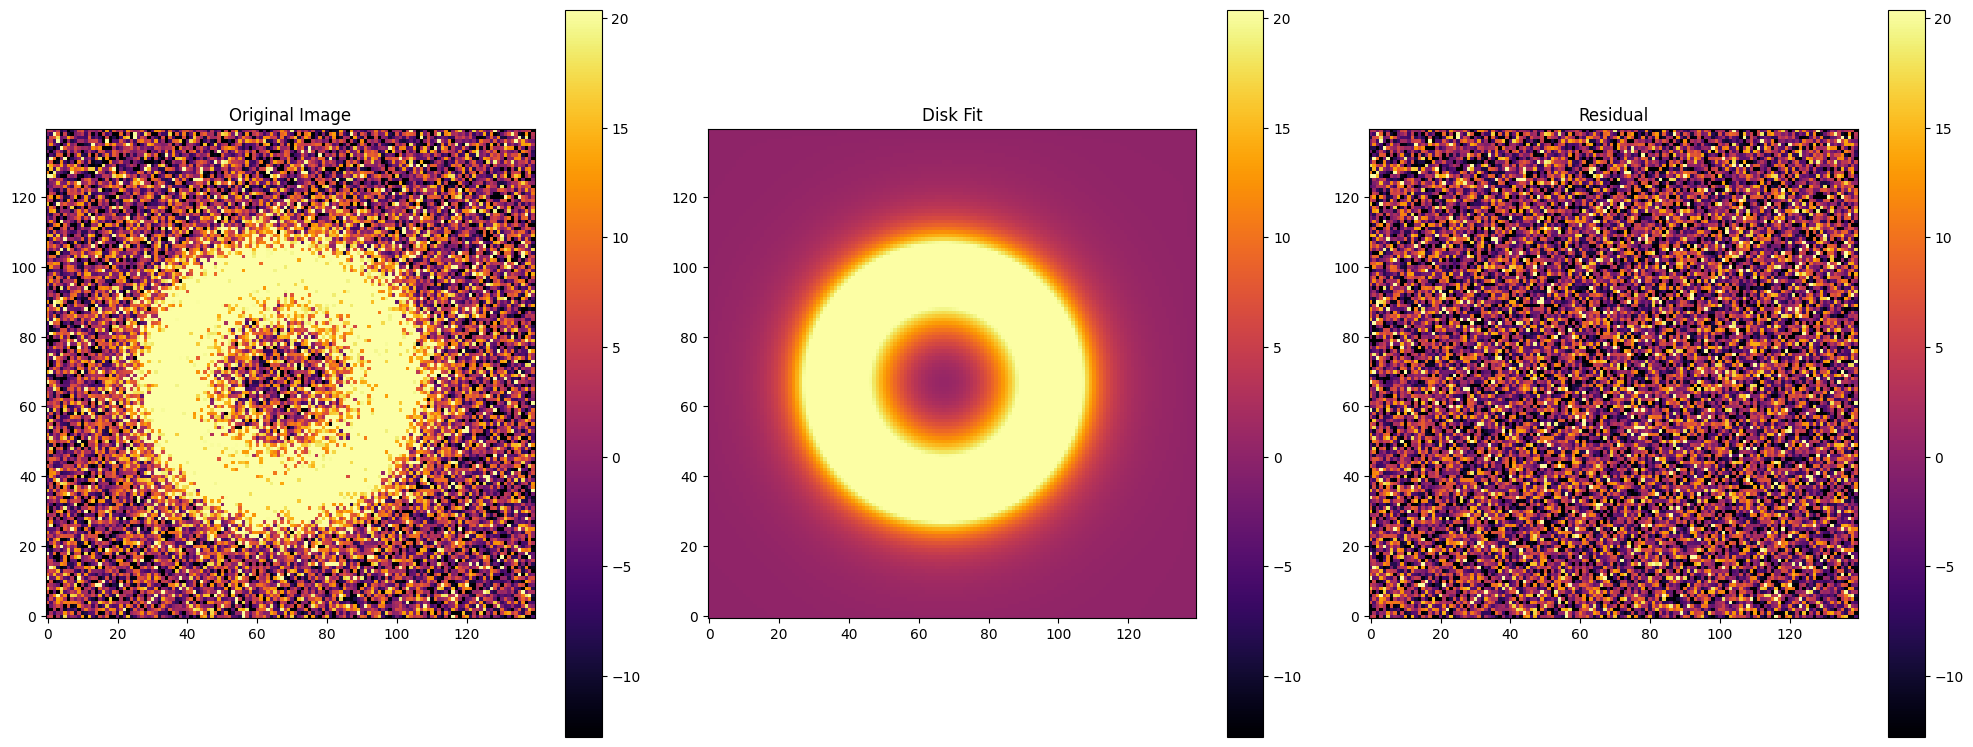

In [11]:
mc_model.set_discarded_iters(1000)
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
plt.savefig('{}_mcmc_img.png'.format(name))

In [12]:
print(np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params))))

[85.         87.50238096 90.         92.49761904 95.        ]


In [13]:
print(opt.disk_params['beta'])

0.5270433368005045


(2500, 100, 9)


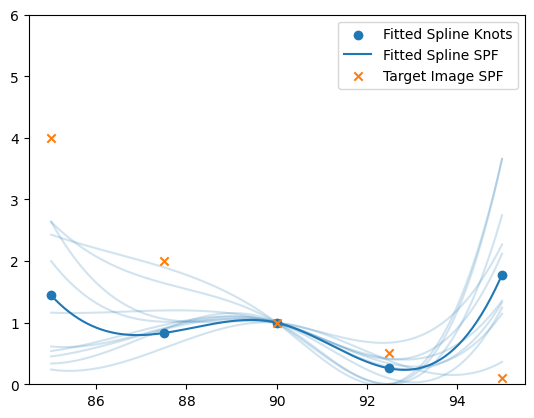

In [14]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(knot_locs,[4.0,2.0,1.0,0.5,0.1],marker='x',zorder=10)
for i in np.random.random(10)*(len(mc_model.scaled_chain)-500):
    j = int(np.random.random()*100)
    i = int(i)+500
    kvals = mc_model.scaled_chain[i,j,4:]
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals)/InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(90),color='tab:blue',alpha=0.2)
plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.ylim(0,6)
print(mc_model.scaled_chain.shape)
plt.savefig('{}_mcmc_spf.png'.format(name))

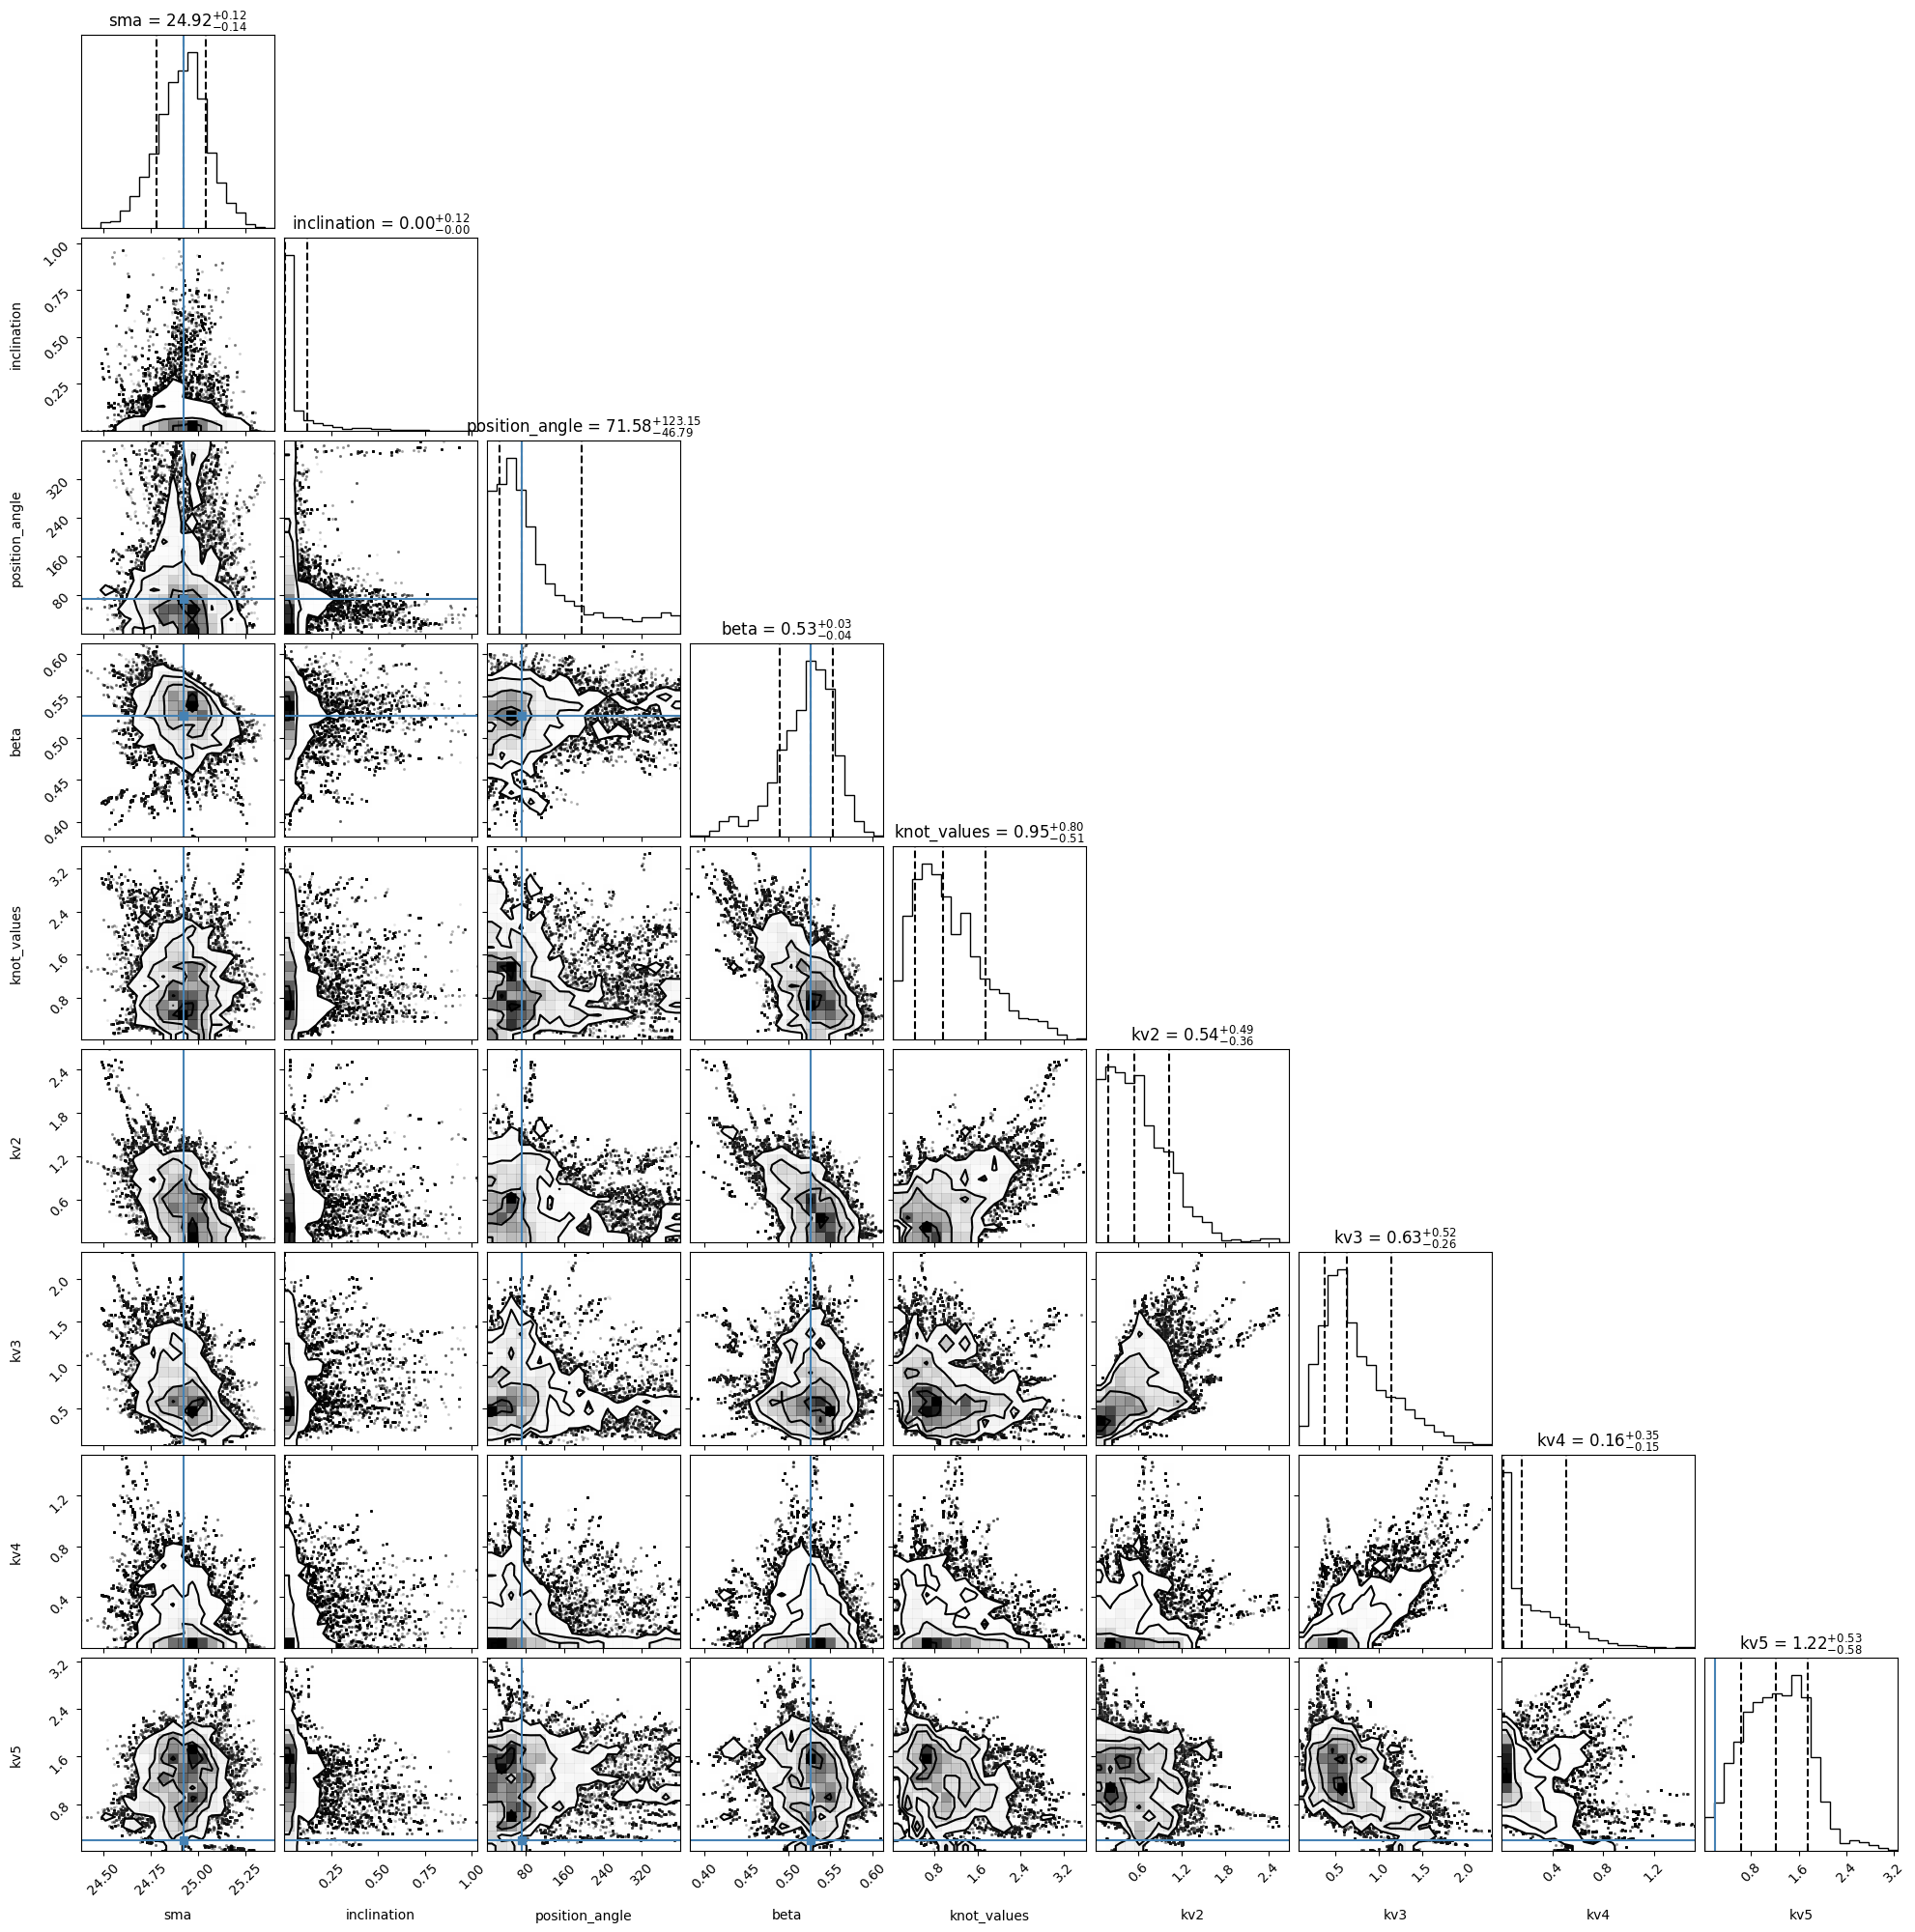

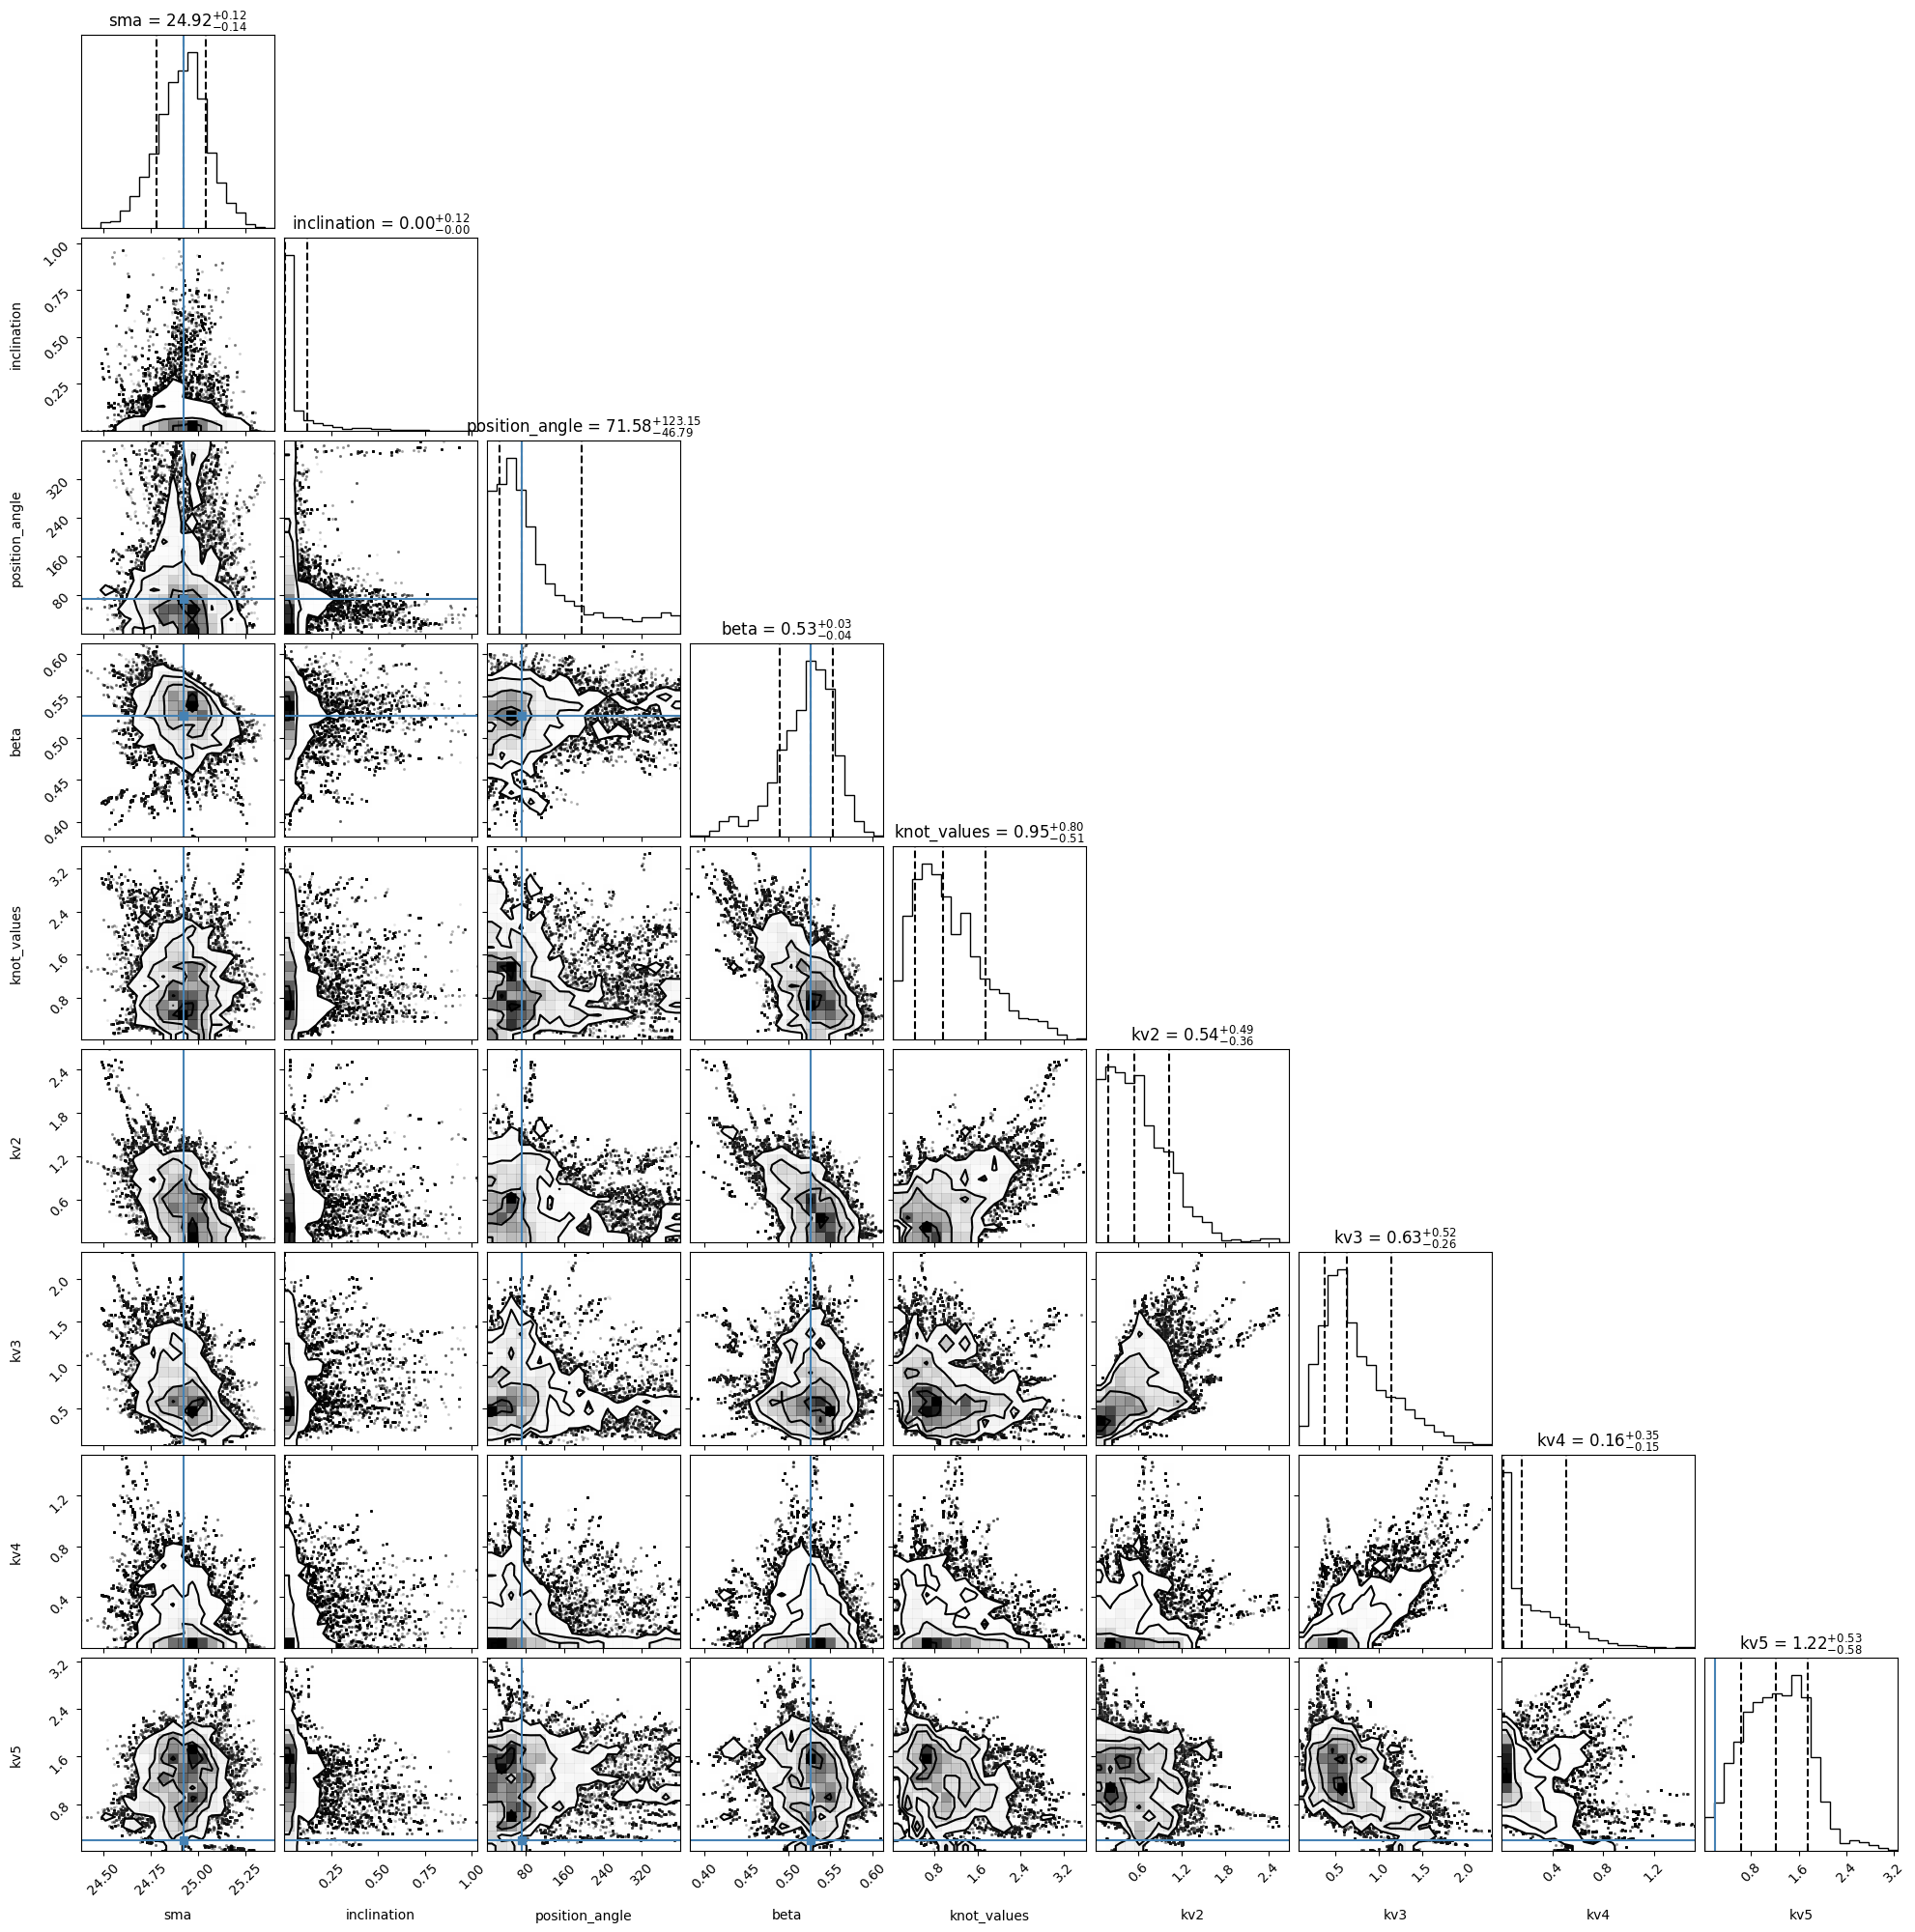

In [15]:
mc_soln = mc_model.get_theta_median()
mc_model.show_corner_plot(fit_keys+['kv2','kv3','kv4','kv5'], truths=mc_soln, scaled=True)


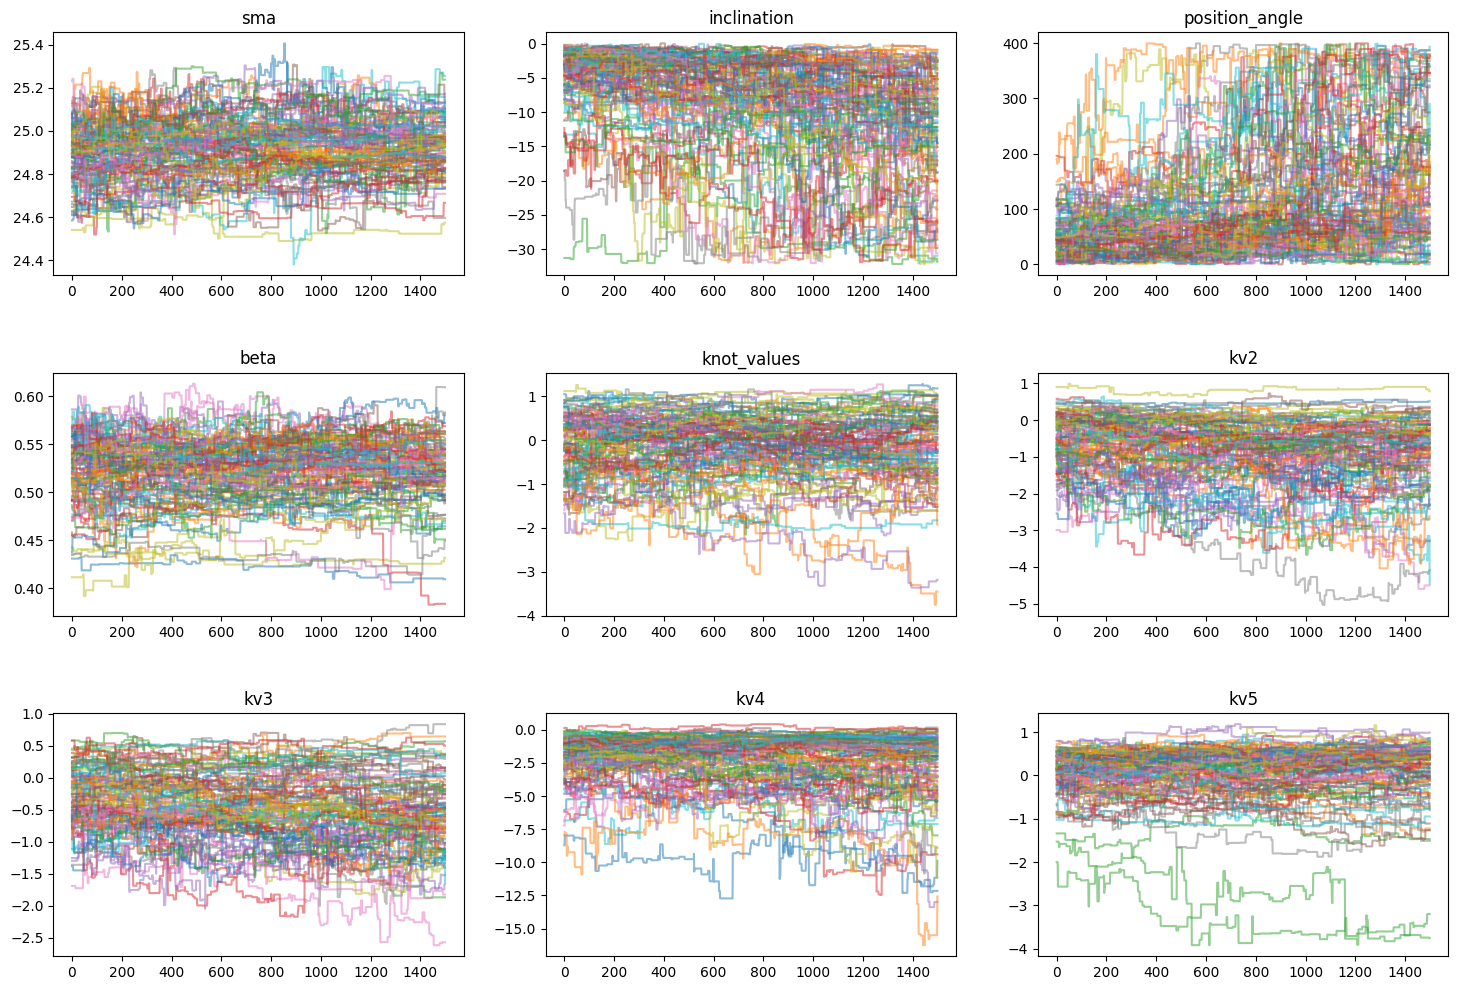

In [16]:
mc_model.plot_chains(fit_keys+['kv2','kv3','kv4','kv5'])